# **AnalystLab Africa - Week 2**
## **Feature Engineering & Data Preprocessing**

### **Project: Heart Disease Prediction**

#### **Objective:**
Prepare the dataset for machine learning by performing data inspection,
cleaning, feature engineering, encoding, scaling, outlier treatment,
and feature selection.

#### **Step 1) Import Libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

### **Step 2) Data Inspection**

### **a) Load the dataset**

In [ ]:
df = pd.read_csv('/content/sample_data/heart.csv')

#### **b) Display the dataset**

In [ ]:
# Display the first 10 rows
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [ ]:
# Display the last 10 rows
df.tail(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
908,63,M,ASY,140,187,0,LVH,144,Y,4.0,Up,1
909,63,F,ASY,124,197,0,Normal,136,Y,0.0,Flat,1
910,41,M,ATA,120,157,0,Normal,182,N,0.0,Up,0
911,59,M,ASY,164,176,1,LVH,90,N,1.0,Flat,1
912,57,F,ASY,140,241,0,Normal,123,Y,0.2,Flat,1
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1
917,38,M,NAP,138,175,0,Normal,173,N,0.0,Up,0


#### **Variable Description**

Let's describe each variable (column) in the dataset:

*   **Age:** Numerical. The age of the patient in years.
    *   `min`: 28, `max`: 77, `mean`: ~53.51. This suggests a relatively broad age range in the dataset.
*   **Sex:** Categorical (object). The gender of the patient (e.g., 'M' for Male, 'F' for Female).
*   **ChestPainType:** Categorical (object). The type of chest pain experienced by the patient. Common types include: `ATA` (Typical Angina), `NAP` (Atypical Angina), `ASY` (Asymptomatic), `TA` (Non-Anginal Pain).
*   **RestingBP:** Numerical. Resting blood pressure in mm Hg (millimetres of mercury).
    *   `min`: 0, `max`: 200, `mean`: ~132.40. The `min` value of 0 for RestingBP might indicate missing or erroneous data, as blood pressure cannot be zero. This will require further investigation during data cleaning.
*   **Cholesterol:** Numerical. Serum cholesterol in mg/dl (milligrams per decilitre).
    *   `min`: 0, `max`: 603, `mean`: ~198.80. Similar to RestingBP, a `min` value of 0 for Cholesterol is unusual and likely represents missing or incorrect data.
*   **FastingBS:** Numerical (binary). Fasting blood sugar > 120 mg/dl (1 = true; 0 = false).
    *   `min`: 0, `max`: 1, `mean`: ~0.23. This indicates that roughly 23% of the patients have fasting blood sugar > 120 mg/dl.
*   **RestingECG:** Categorical (object). Resting electrocardiogram results. Types include: `Normal`, `ST` (ST-T wave abnormality), `LVH` (left ventricular hypertrophy).
*   **MaxHR:** Numerical. Maximum heart rate achieved during exercise.
    *   `min`: 60, `max`: 202, `mean`: ~136.81.
*   **ExerciseAngina:** Categorical (object). Exercise-induced angina (Y = yes; N = no).
*   **Oldpeak:** Numerical. ST depression induced by exercise relative to rest.
    *   `min`: -2.6, `max`: 6.2, `mean`: ~0.89.
*   **ST_Slope:** Categorical (object). The slope of the peak exercise ST segment. Types include: `Up` (upsloping), `Flat`, `Down` (downsloping).
*   **HeartDisease:** Numerical (binary - target variable). The presence of heart disease (1 = yes; 0 = no).
    *   `min`: 0, `max`: 1, `mean`: ~0.55. This indicates that about 55% of the individuals in the dataset have heart disease, suggesting a relatively balanced target variable.

#### **c) Data Shape**

In [ ]:
df.shape

(918, 12)

##### **Interpretation**

*   The dataset has 918 rows and 12 columns.

**b) Data types**

In [ ]:
# undrestand the datatypes
df.dtypes

,0
Age,int64
Sex,object
ChestPainType,object
RestingBP,int64
Cholesterol,int64
FastingBS,int64
RestingECG,object
MaxHR,int64
ExerciseAngina,object
Oldpeak,float64


##### **Interpretation of Data Types**

*   **`int64` (Integer):** These columns store whole numbers. In this dataset, `Age`, `RestingBP`, `Cholesterol`, `FastingBS`, `MaxHR`, and `HeartDisease` are `int64`. This is appropriate for counts or numerical measurements without decimal points.

*   **`object` (String/Categorical):** These columns typically store text or mixed data types. In this dataset, `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, and `ST_Slope` are `object` type. This indicates they contain categorical data, which will likely need encoding (e.g., one-hot encoding or label encoding) for machine learning models.

*   **`float64` (Floating-point number):** This column stores numbers with decimal points. `Oldpeak` is a `float64`, which is suitable for measurements that can have fractional values.

#### **c) Missing values**

In [ ]:
# check for missing values
df.isnull().sum()

,0
Age,0
Sex,0
ChestPainType,0
RestingBP,0
Cholesterol,0
FastingBS,0
RestingECG,0
MaxHR,0
ExerciseAngina,0
Oldpeak,0


##### **Interpretation**
*   List itemThere are **no missing values** in any of the columns.



#### **d) Duplicate records**

In [ ]:
# check for duplicate records
df.duplicated().sum()

np.int64(0)

##### **Interpretation**


*   There are no duplicate records present in the dataset




#### **e) Summary Satistics**

In [ ]:
# Display descriptive statistics for numerical columns
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


**Interpretation of Numerical Columns :**

*   **Age:** Ranges from 28 to 77 years, with an average age of approximately 53.5 years. The standard deviation of about 9.4 indicates a moderate spread in age.
*   **RestingBP:** Ranges from 0 to 200 mm Hg, with a mean of around 132.4. Note: The minimum value of 0 is highly anomalous for blood pressure and likely indicates missing or incorrectly recorded data. This will need to be addressed during data cleaning.
*   **Cholesterol:** Ranges from 0 to 603 mg/dl, with a mean of about 198.8. Note: Similar to RestingBP, a minimum cholesterol of 0 is physiologically impossible and suggests data entry errors or missing values that were coded as 0. This also requires attention during data cleaning.
*   **FastingBS:** This is a binary variable (0 or 1). The mean of 0.233 indicates that approximately 23.3% of the patients have fasting blood sugar greater than 120 mg/dl.
*   **MaxHR:** Maximum heart rate achieved ranges from 60 to 202 bpm, with an average of about 136.8 bpm.
*   **Oldpeak:** ST depression ranges from -2.6 to 6.2, with a mean of 0.887. The negative minimum value indicates ST elevation (inverse depression).
*   **HeartDisease:** This is the target binary variable (0 or 1). The mean of 0.553 indicates that approximately 55.3% of the patients in the dataset have heart disease, suggesting a slightly imbalanced but manageable dataset for classification.


In [ ]:
df.describe(include='object')

,Sex,ChestPainType,RestingECG,ExerciseAngina,ST_Slope
count,918,918,918,918,918
unique,2,4,3,2,3
top,M,ASY,Normal,N,Flat
freq,725,496,552,547,460


##### **Interpretation of Categorical Columns :**

*   **Sex:** There are 2 unique values. 'M' (Male) is the most frequent category, appearing 725 times.
*   **ChestPainType:** There are 4 unique values. 'ASY' (Asymptomatic) is the most frequent, occurring 496 times.
*   **RestingECG:** There are 3 unique values. 'Normal' is the most frequent, appearing 552 times.
*   **ExerciseAngina:** There are 2 unique values. 'N' (No) is the most frequent, occurring 547 times.
*   **ST_Slope:** There are 3 unique values. 'Flat' is the most frequent, appearing 460 times.



### **Step 3) Feature Engineering & Data Preprocessing**

##### **A) Data Cleaning**

##### **i) Handling missing values**

In [ ]:
# Create a copy of the original DataFrame and store it in a new variable called 'clean'.
# This allows us to clean or modify the data without changing the original DataFrame 'df'.
clean = df.copy()

In [ ]:
# Display the names of all columns in the 'clean' DataFrame
clean.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

##### **Before handling missing Cholesterol values**

  *   Identify where the missing Cholesterol values exist

In [ ]:
# Display all the unique values found in the Cholesterol column

clean["Cholesterol"].unique()

array([289, 180, 283, 214, 195, 339, 237, 208, 207, 284, 211, 164, 204,
       234, 273, 196, 201, 248, 267, 223, 184, 288, 215, 209, 260, 468,
       188, 518, 167, 224, 172, 186, 254, 306, 250, 177, 227, 230, 294,
       264, 259, 175, 318, 216, 340, 233, 205, 245, 194, 270, 213, 365,
       342, 253, 277, 202, 297, 225, 246, 412, 265, 182, 218, 268, 163,
       529, 100, 206, 238, 139, 263, 291, 229, 307, 210, 329, 147,  85,
       269, 275, 179, 392, 466, 129, 241, 255, 276, 282, 338, 160, 156,
       272, 240, 393, 161, 228, 292, 388, 166, 247, 331, 341, 243, 279,
       198, 249, 168, 603, 159, 190, 185, 290, 212, 231, 222, 235, 320,
       187, 266, 287, 404, 312, 251, 328, 285, 280, 192, 193, 308, 219,
       257, 132, 226, 217, 303, 298, 256, 117, 295, 173, 315, 281, 309,
       200, 336, 355, 326, 171, 491, 271, 274, 394, 221, 126, 305, 220,
       242, 347, 344, 358, 169, 181,   0, 236, 203, 153, 316, 311, 252,
       458, 384, 258, 349, 142, 197, 113, 261, 310, 232, 110, 12

In [ ]:
# Check for invalid zero values
print("Cholesterol zeros:", (clean["Cholesterol"] == 0).sum())

Cholesterol zeros: 172


##### **Interference**
*   There are 172 records where the Cholesterol value is 0.


##### **Replace the missing values with the Cholesterol median**

##### **Replacing 0 with NaN values**

In [ ]:
# Replace cholesterol values of 0 with NaN
clean["Cholesterol"] = clean["Cholesterol"].replace(0, np.nan)

In [ ]:
# Count missing values in the Cholesterol column
print("Missing Cholesterol values:", clean["Cholesterol"].isna().sum())

Missing Cholesterol values: 172


In [ ]:
# Display all rows that contain at least one missing (NaN) value
clean[clean.isna().any(axis=1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
293,65,M,ASY,115,NaN,0,Normal,93,Y,0.0,Flat,1
294,32,M,TA,95,NaN,1,Normal,127,N,0.7,Up,1
295,61,M,ASY,105,NaN,1,Normal,110,Y,1.5,Up,1
296,50,M,ASY,145,NaN,1,Normal,139,Y,0.7,Flat,1
297,57,M,ASY,110,NaN,1,ST,131,Y,1.4,Up,1
...,...,...,...,...,...,...,...,...,...,...,...,...
514,43,M,ASY,122,NaN,0,Normal,120,N,0.5,Up,1
515,63,M,NAP,130,NaN,1,ST,160,N,3.0,Flat,0
518,48,M,NAP,102,NaN,1,ST,110,Y,1.0,Down,1
535,56,M,ASY,130,NaN,0,LVH,122,Y,1.0,Flat,1


##### **Calculating the median of Cholesterol values**

In [ ]:
# Calculate the median cholesterol level using only non-missing (non-NaN) values
median_cholesterol = clean['Cholesterol'].dropna().median()

# Display the median cholesterol level
print('Median Cholesterol:', median_cholesterol)

Median Cholesterol: 237.0


##### **Interference**
*   The **median cholesterol level** is **237.0** among the non-NaN cholesterol values

In [ ]:
# Replace missing values with the calculated median
clean["Cholesterol"] = clean["Cholesterol"].fillna(median_cholesterol)

##### **After handling missing Cholesterol values**

In [ ]:
# Display unique values
clean["Cholesterol"].unique()

array([289., 180., 283., 214., 195., 339., 237., 208., 207., 284., 211.,
       164., 204., 234., 273., 196., 201., 248., 267., 223., 184., 288.,
       215., 209., 260., 468., 188., 518., 167., 224., 172., 186., 254.,
       306., 250., 177., 227., 230., 294., 264., 259., 175., 318., 216.,
       340., 233., 205., 245., 194., 270., 213., 365., 342., 253., 277.,
       202., 297., 225., 246., 412., 265., 182., 218., 268., 163., 529.,
       100., 206., 238., 139., 263., 291., 229., 307., 210., 329., 147.,
        85., 269., 275., 179., 392., 466., 129., 241., 255., 276., 282.,
       338., 160., 156., 272., 240., 393., 161., 228., 292., 388., 166.,
       247., 331., 341., 243., 279., 198., 249., 168., 603., 159., 190.,
       185., 290., 212., 231., 222., 235., 320., 187., 266., 287., 404.,
       312., 251., 328., 285., 280., 192., 193., 308., 219., 257., 132.,
       226., 217., 303., 298., 256., 117., 295., 173., 315., 281., 309.,
       200., 336., 355., 326., 171., 491., 271., 27

In [ ]:
# Count the remaining missing (NaN) values in the Cholesterol column
print("Remaining NaN values:", clean["Cholesterol"].isna().sum())

Remaining NaN values: 0


##### **Interference**
*   There are 0 records where the Cholesterol value is NaN.

##### **Before handling missing RestingBP values**
 *   Identify where the missing RestingBP values exist

In [ ]:
clean['RestingBP'].unique()

array([140, 160, 130, 138, 150, 120, 110, 136, 115, 100, 124, 113, 125,
       145, 112, 132, 118, 170, 142, 190, 135, 180, 108, 155, 128, 106,
        92, 200, 122,  98, 105, 133,  95,  80, 137, 185, 165, 126, 152,
       116,   0, 144, 154, 134, 104, 139, 131, 141, 178, 146, 158, 123,
       102,  96, 143, 172, 156, 114, 127, 101, 174,  94, 148, 117, 192,
       129, 164])

In [ ]:
# Check for invalid zero values
print('RestingBP zeros:', (clean['RestingBP'] == 0).sum())


RestingBP zeros: 1


##### **Interpretation**
*   RestingBP column currently contains 1 missing 0 value.

In [ ]:
# Display records containing zero values
clean[(clean["RestingBP"] == 0)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,0,237.0,0,Normal,155,N,1.5,Flat,1


##### **Replacing 0 with NaN values**

In [ ]:
# Replace RestingBP values of 0 with NaN
clean["RestingBP"] = clean["RestingBP"].replace(0, np.nan)

In [ ]:
# Count missing values in the RestingBP column
print("Missing RestingBP values:", clean["RestingBP"].isna().sum())

Missing RestingBP values: 1


##### **Interpretation**
*   RestingBP column currently contains 1 missing (NaN) value.

In [ ]:
# Display all rows that contain at least one missing (NaN) value
clean[clean.isna().any(axis=1)]

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
449,55,M,NAP,NaN,237.0,0,Normal,155,N,1.5,Flat,1


##### **Calculating the median of RestingBP values**

In [ ]:
# Calculate the median RestingBP level using only non-missing (non-NaN) values
median_RestingBP = clean['RestingBP'].dropna().median()

# Display the median cholesterol level
print('Median RestingBP:', median_RestingBP)

Median RestingBP: 130.0


##### **Interference**
*   The **median RestingBP value** is **130.0** among the non-NaN cholesterol values

In [ ]:
# Replace missing values with the calculated median
clean['RestingBP'] = clean['RestingBP'].fillna(median_RestingBP)

##### **After handling missing RestingBP values**

In [ ]:
# Display unique values
clean['RestingBP'].unique()

array([140., 160., 130., 138., 150., 120., 110., 136., 115., 100., 124.,
       113., 125., 145., 112., 132., 118., 170., 142., 190., 135., 180.,
       108., 155., 128., 106.,  92., 200., 122.,  98., 105., 133.,  95.,
        80., 137., 185., 165., 126., 152., 116., 144., 154., 134., 104.,
       139., 131., 141., 178., 146., 158., 123., 102.,  96., 143., 172.,
       156., 114., 127., 101., 174.,  94., 148., 117., 192., 129., 164.])

In [ ]:
# Count the remaining missing (NaN) values in the "RestingBP column
print('Remaining NaN values:', clean['RestingBP'].isna().sum())

Remaining NaN values: 0


##### **Interference**
*   There are 0 records where the RestingBP value is 0.

In [ ]:
clean.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

##### **Justification**
*   Zero values were identified in the RestingBP and Cholesterol variables.
*   Since zero represents an invalid values for these variables, these observations were treated as missing/invalid values.
*   I then replaced invalid values of 0 with **NaN** because treating them as real values would distort your analysis, and Python would treat the zeros as actual values.
*   By converting them to **NaN**:

      *   Python can recognise those values as missing.
      *   It also makes missing-value handling easier.
      *   Then I replaced the missing values with the median:

##### **ii) Remove Duplicates**

In [ ]:
dup_val = clean.duplicated().any().sum()
dup_val

np.int64(0)

In [ ]:
clean.shape

(918, 12)

##### **Interpretation**
*   **Original rows:** 918
*   **Duplicate rows found:** 0
*   **Rows after removal:** 918

This indicates that the dataset had no duplicate records, so the `clean` DataFrame retains all original rows.

##### **iii) Correct Data types**

  *   Display the info and head of the `clean` DataFrame is to verify the data types, non-null counts, and the visual state of the DataFrame after the initial cleaning steps.

In [ ]:
clean.info()
clean.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    float64
 4   Cholesterol     918 non-null    float64
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 86.2+ KB


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120.0,339.0,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130.0,237.0,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110.0,208.0,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140.0,207.0,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120.0,284.0,0,Normal,120,N,0.0,Up,0


### **Data after cleaning**

In [ ]:
from google.colab import files

# Save the cleaned DataFrame to a CSV file
output_filename_cleaned = 'cleaned_heart_disease_data.csv'
clean.to_csv(output_filename_cleaned, index=False)

# Provide a link to download the file
files.download(output_filename_cleaned)

print(f"The cleaned dataset (before feature engineering) has been saved to '{output_filename_cleaned}' and is available for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The cleaned dataset (before feature engineering) has been saved to 'cleaned_heart_disease_data.csv' and is available for download.


### **Exploratory Data Analysis**

In [ ]:
clean.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0


### **a) Univariate Analysis**

#### **i) Target Variable (HeartDisease)**

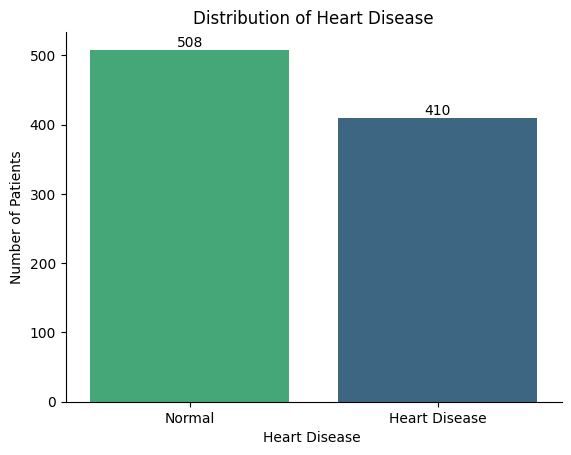

In [ ]:

# Create a countplot for the 'HeartDisease' column.
# sort the bars by count in descending order
ax= sns.countplot(data = clean, x='HeartDisease',  hue = 'HeartDisease',  legend=False,
              order = clean['HeartDisease'].value_counts(ascending=False).index, palette='viridis')


# Add a title to the chart.
plt.title("Distribution of Heart Disease")

# Add label to x-axis
plt.xlabel('Heart Disease ')

# Add label to y-axis
plt.ylabel('Number of Patients')

# Replace the numerical x-axis labels with more descriptive labels.
plt.xticks([0, 1], ['Normal', 'Heart Disease'])

# Add labels to the top of each bar.
for container in ax.containers:
    ax.bar_label(container)

# Remove the top and right spines (borders) of the plot for a cleaner look.
sns.despine(top=True, right=True)

# Display the plot.
plt.show()



##### **Interpretation**
*   This indicates that there are 508 patients with heart disease and 410 patients without heart disease(Normal).



#### **ii) Univariate Analysis for Other Numerical Columns**

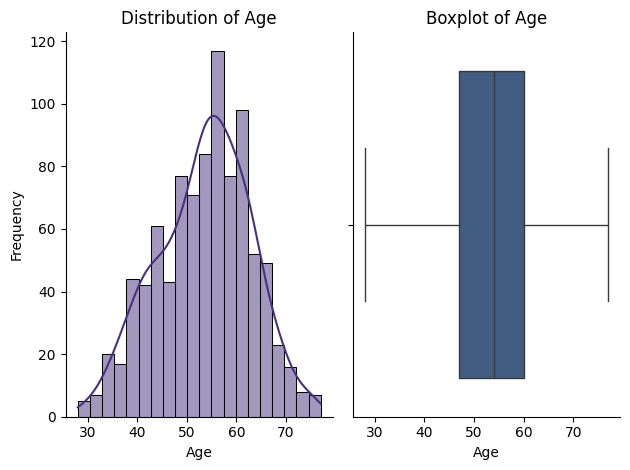

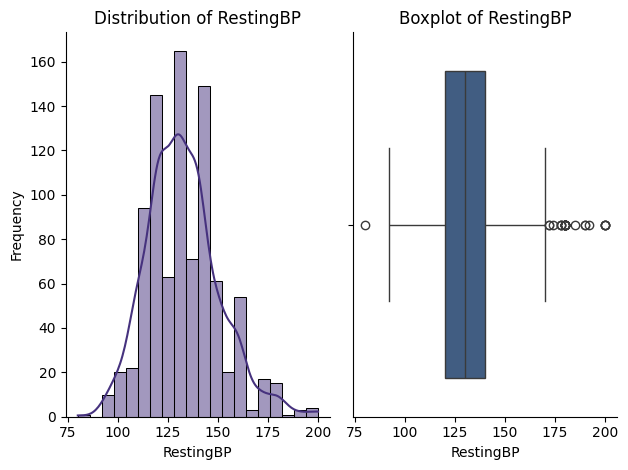

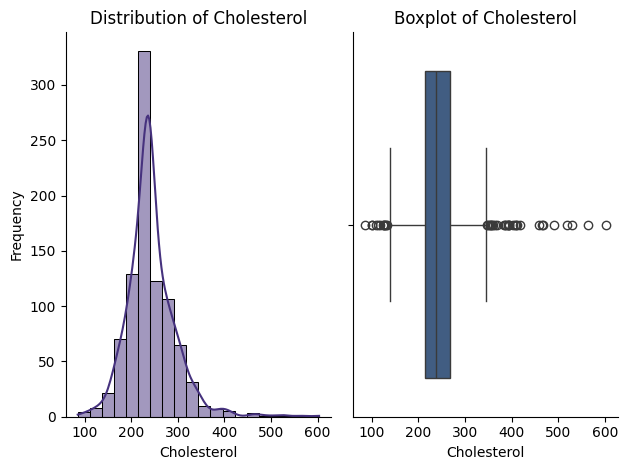

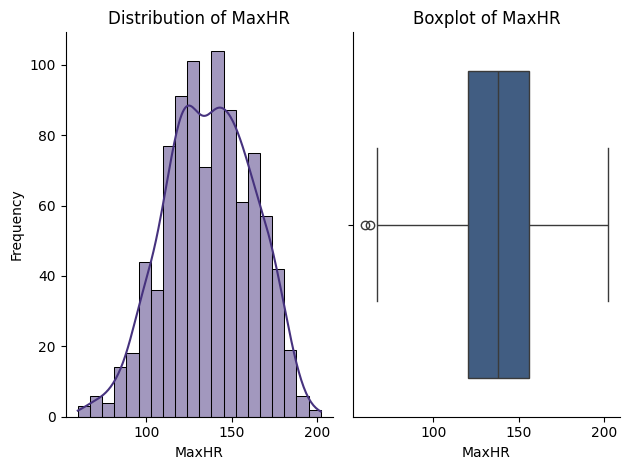

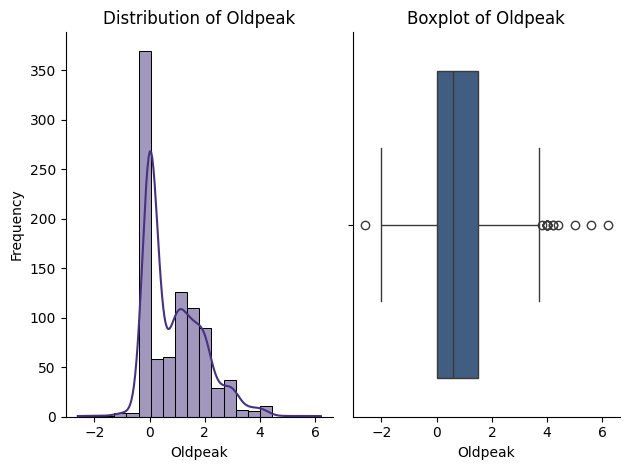

In [ ]:

# Create a list of numerical columns that will be used for analysis
numerical_cols_for_analysis = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Loop through each numerical column in the list
for col in numerical_cols_for_analysis:

    # Create a histogram
    plt.subplot(1, 2, 1)
    sns.histplot(data=clean, x=col, bins=20, kde=True, color=sns.color_palette('viridis')[0])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Remove the top and right spines (borders) of the plot for a cleaner look.
    sns.despine(top=True, right=True)

    # Create a boxplot
    plt.subplot(1, 2, 2)
    sns.boxplot(data=clean, x=col, color=sns.color_palette('viridis')[1])
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()

    # Remove the top and right spines (borders) of the plot for a cleaner look.
    sns.despine(top=True, right=True)
    plt.show()

##### **Interpretation**
##### **Age:**
##### **Histogram:**
*   Age is fairly spread, ranging from 28 to 77 years, with a mean around 53.5 years.
*   The distribution is normal or slightly left-skewed.

##### **Boxplot:**
*   This indicates a moderate spread without significant extreme outliers.

##### **RestingBP:**
##### **Histogram:**
*   Resting Blood Pressure ranges from 0 to 200 mm Hg, with a mean of about 132.4.
*   There is the presence of a minimum value of 0, which is anomalous.

##### **Boxplot:**
*   This shows some variability and potential outliers at higher values.

##### **Cholesterol:**
##### Histogram
*   Cholesterol values range from 0 to 603 mg/dl, with a mean of about 198.8.
*   Similar to RestingBP, the initial analysis identified anomalous 0 values, which will be treated as missing.

##### **Boxplot:**
*   This shows potential outliers, with some patients having very high cholesterol levels

##### **MaxHR:**
##### **Histogram:**
*   Maximum Heart Rate during exercise varies from 60 to 202 bpm, with an average of 136.8 bpm.
*   MaxHR  is relatively symmetrical or slightly skewed distribution.

##### **Boxplot:**
*   This shows outliers at both lower and higher ends.

##### **Oldpeak:**
##### **Histogram:**

*   ST depression ranges from -2.6 to 6.2, With a mean of 0.887.
*   ST depression shows a right-skewed distribution, with many values clustered around zero or slightly positive, and a long tail extending to higher positive values.

##### **Boxplot:**
 *  Indicates a number of positive outliers, suggesting some patients experience significantly higher ST depression, and a few negative outliers indicating ST elevation, which were also capped during outlier treatment.

##### **Conclusion**
##### **Age:**
*   Shows a moderate spread, with a typical distribution for an adult population.
*   No significant anomalies were observed.

##### **RestingBP & Cholesterol:**
*   Both initially contained anomalous '0' values, which were treated as missing and imputed with their respective medians.
*   After cleaning, their distributions appear more physiological, though some higher values might still be present.

##### **MaxHR:**

*   Exhibits a relatively symmetrical distribution with a normal range, though some outliers at both ends.

##### **Oldpeak:**
*   Displayed a right-skewed distribution, indicating many values around zero or slightly positive,
*   There is a noticeable presence of positive outliers.
*   This suggests a varied ST depression response among the patient population.

#### **iii) Univariate Analysis for FastingBS**

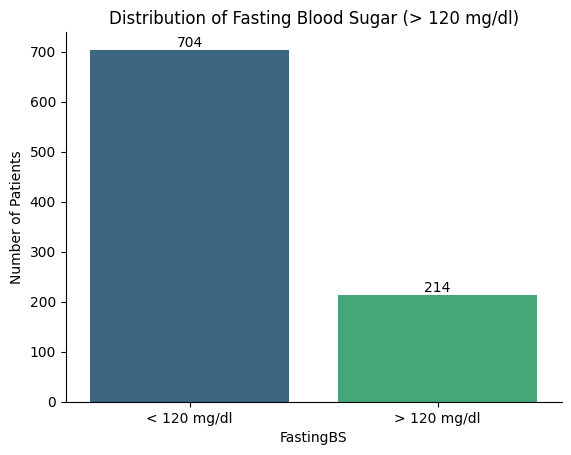

In [ ]:
# Create a count plot to show the number of patients
# in each fasting blood sugar category.
sns.countplot(data=clean, x='FastingBS', hue='FastingBS', palette='viridis', legend=False)


# Add a title to the chart.
plt.title('Distribution of Fasting Blood Sugar (> 120 mg/dl)')

# Label the x-axis.
plt.xlabel('FastingBS')

# Label the y-axis to show the number of patients.
plt.ylabel('Number of Patients')

# Replace the numerical values 0 and 1 with descriptive labels.
# 0 represents fasting blood sugar <= 120 mg/dL.
# 1 represents fasting blood sugar > 120 mg/dL.
plt.xticks([0, 1], ['< 120 mg/dl', '> 120 mg/dl'])



# Add count labels on top of bars
for container in plt.gca().containers:
    plt.gca().bar_label(container)


# Remove the top and right spines (borders) of the plot for a cleaner look.
sns.despine(top=True, right=True)


plt.show()

##### **Interpretation:**
###### **FastingBS = 0 (< 120 mg/dl):**
*    A larger portion of patients (704 individuals) have fasting blood sugar levels less than or equal to 120 mg/dl.

###### **FastingBS = 1 (> 120 mg/dl):**
*   A smaller group of patients (214 individuals) have fasting blood sugar levels greater than 120 mg/dl.



##### **Conclusion:**
*   According to this threshold, most of patients in the dataset do not have elevated fasting blood sugar.

#### **Univariate Analysis for Categorical Columns**

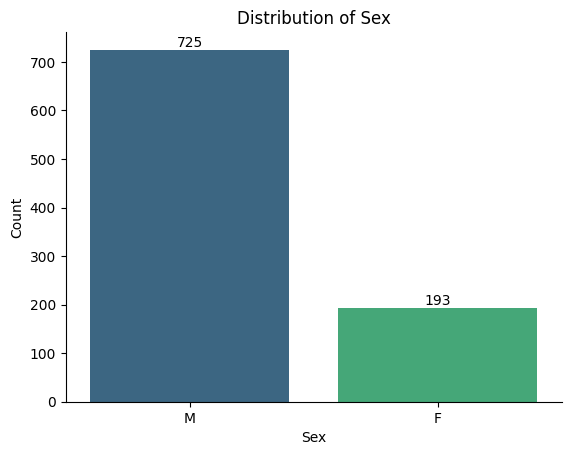

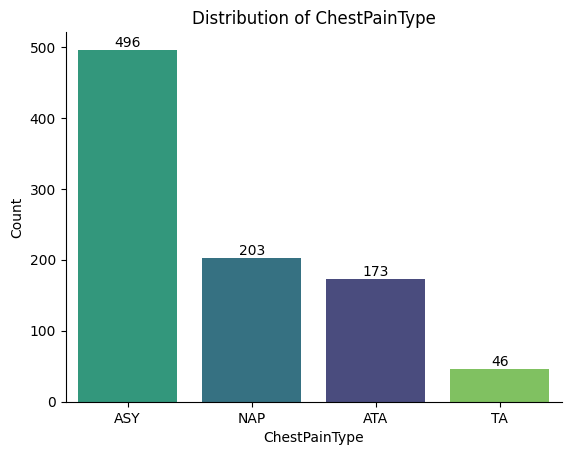

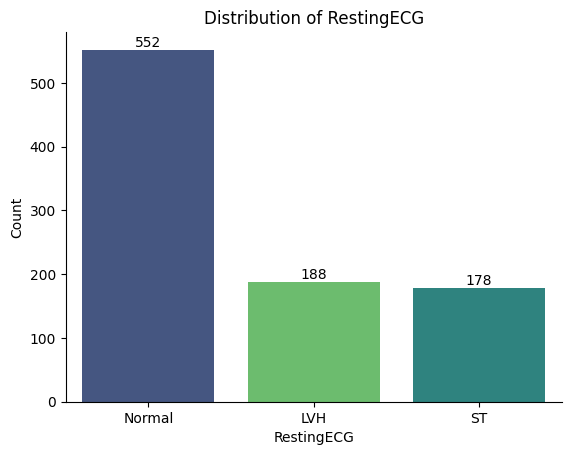

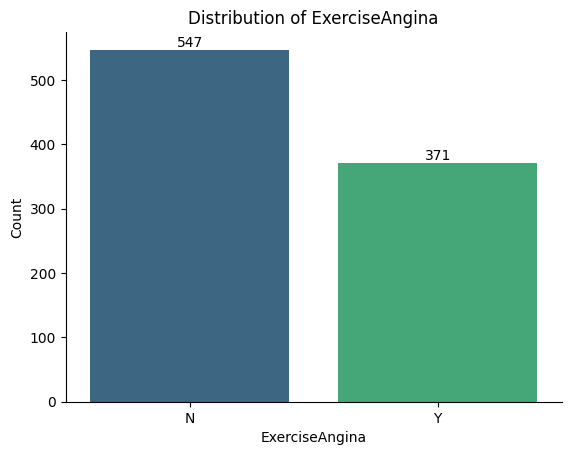

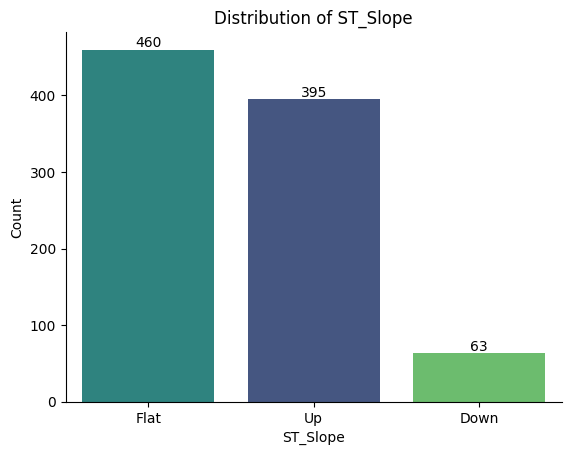

In [ ]:
# Create a list of categorical columns to analyse
categorical_cols_for_analysis = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


# Loop through each categorical column
for col in categorical_cols_for_analysis:


    # Create a count plot showing the frequency of each category
    # The categories are ordered from most common to least common
    ax = sns.countplot(data=clean, x=col, hue=col, palette='viridis', legend=False, order=clean[col].value_counts().index)

     # Add a title showing which variable is being displayed
    plt.title(f'Distribution of {col}')

    # Label the x-axis with the column name
    plt.xlabel(col)

    # Label the y-axis to show the number of records in each category
    plt.ylabel('Count')



     # Add count labels on top of bars
    for container in ax.containers:
        ax.bar_label(container)
    # Remove the top and right spines (borders) of the plot for a cleaner look.
    sns.despine(top=True, right=True)

     # Display the plot
    plt.show()

##### **Interpretation**
##### **Sex:**
 *   The dataset is predominantly male, with a significantly higher count of male (M) patients compared to female (F) patients.
*   This imbalance should be considered in further analysis.

##### **ChestPainType:**
*   The most common chest pain type is 'ASY' (Asymptomatic), indicating that a large portion of patients experience heart conditions without typical chest pain symptoms
*   This is followed by 'ATA' (Typical Angina) and 'NAP' (Atypical Angina), with 'TA' (Non-Anginal Pain) being the least frequent.

##### **RestingECG**:
*   The 'Normal' resting electrocardiogram result is the most prevalent, followed by 'LVH' (left ventricular hypertrophy) and 'ST' (ST-T wave abnormality).
*   This shows that a majority of patients have normal ECG readings.

##### **ExerciseAngina:**
*   Most patients do not experience exercise-induced angina ('N') compared to those who do ('Y').

##### **ST_Slope:**
*   The 'Flat' ST_Slope is the most common, followed by 'Up' (upsloping) and 'Down' (downsloping).

*   The prevalence of 'Flat' and 'Up' segments suggests different physiological responses to exercise in this patient cohort.

##### **Conclusion:**
##### **Sex:**
*   Sex shows a clear imbalance, with a significantly higher proportion of male patients.
*   This demographic characteristic could influence heart disease prevalence and should be considered in modeling.

##### **ChestPainType:**
*   Asymptomatic chest pain (ASY) is the most common type, highlighting that many patients might have heart disease without experiencing typical chest pain, making diagnosis challenging.
*    Other types (ATA, NAP, TA) are less frequent.

##### **RestingECG:**
*   Most patients have 'Normal' resting ECG results, followed by 'LVH' and 'ST' abnormalities.
*   This indicates that a normal ECG doesn't rule out heart disease in all cases.

##### **ExerciseAngina:**
*   Most patients do not experience exercise-induced angina, suggesting that while it's a known symptom, its absence doesn't exclude heart disease.

##### **ST_Slope:**
*   A 'Flat' ST_Slope is the most common finding, followed by 'Up' and 'Down'.
*    This is important as ST segment changes during exercise are critical indicators of cardiac health.


#### **B) Feature Engineering**

##### **i) Create new features**

In [ ]:
clean.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Age_Group,BP_Category
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0,Young,Hypertension
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1,Middle-Aged,Hypertension
2,37,M,ATA,130.0,283.0,0,ST,98,N,0.0,Up,0,Young,Elevated
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1.5,Flat,1,Middle-Aged,Elevated
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0.0,Up,0,Middle-Aged,Hypertension


#### **Bivariate Analysis**



#### **Numerical vs Numerical**

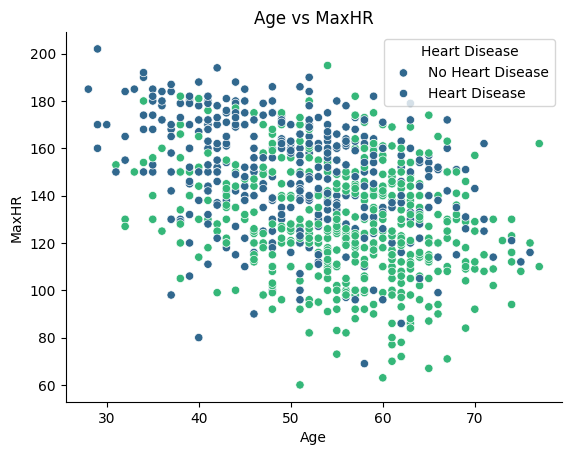

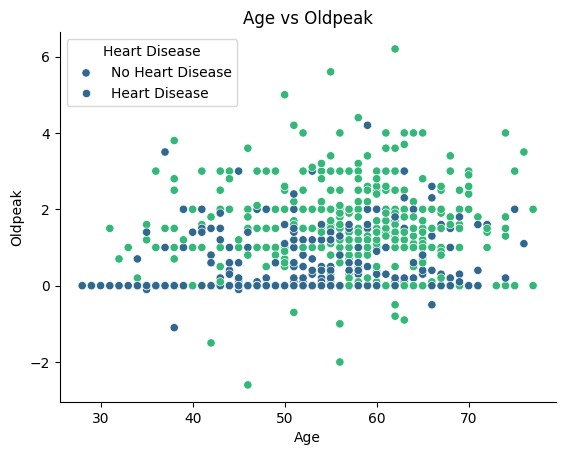

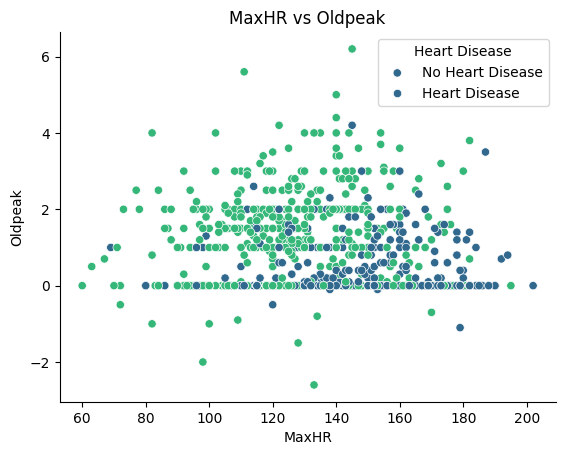

In [ ]:
# Create a list of numerical feature pairs to analyse.

feature_pairs = [
    ('Age', 'MaxHR'),
    ('Age', 'Oldpeak'),
    ('MaxHR', 'Oldpeak')
]


# Loop through each pair of numerical features.

for x_col, y_col in feature_pairs:

    # Create a scatterplot showing the relationship between the two features.
    # Points are coloured according to HeartDisease.

    ax = sns.scatterplot(
        data=clean,
        x=x_col,
        y=y_col,
        hue='HeartDisease',
        palette='viridis'
    )

    # Add a title to the chart.

    plt.title(f'{x_col} vs {y_col}')

    # Add a label to the x-axis.

    plt.xlabel(x_col)

    # Add a label to the y-axis.

    plt.ylabel(y_col)

    # Change the legend labels to more meaningful names.

    ax.legend(
        title='Heart Disease',
        labels=['No Heart Disease', 'Heart Disease']
    )

    # Remove the top and right borders for a cleaner look.

    sns.despine(top=True, right=True)

    # Display the plot.

    plt.show()

##### **Interpretation**
**a. Numerical vs Numerical Features:**

*   **Age vs. MaxHR:** Generally, as age increases, the maximum heart rate tends to decrease, indicating an inverse relationship. This is a known physiological response. The relationship might also show different patterns between those with and without heart disease.
*   **Age vs. Oldpeak:** Older patients tend to exhibit higher `Oldpeak` values, suggesting a positive correlation where older individuals are more likely to have greater ST depression during exercise.
*   **MaxHR vs. Oldpeak:** There appears to be an inverse relationship, where lower maximum heart rates are associated with higher `Oldpeak` values. This suggests that patients with a reduced ability to raise their heart rate during exercise might experience more pronounced ST depression.


#### **Numerical columns against HeartDisease**

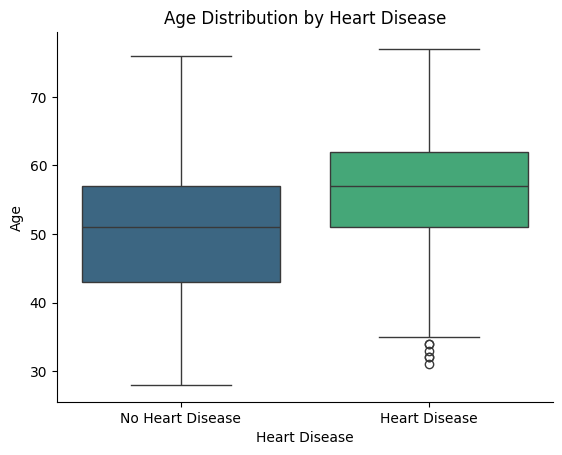

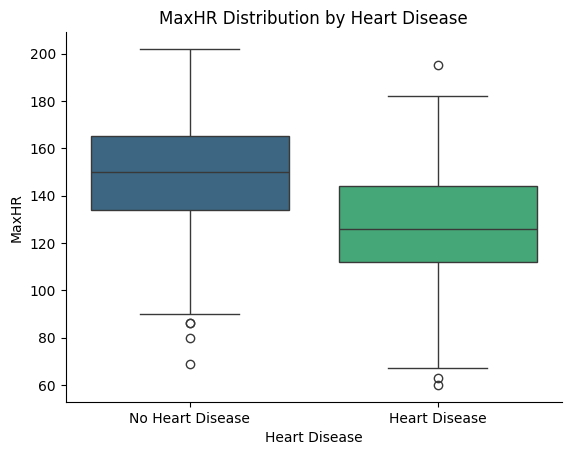

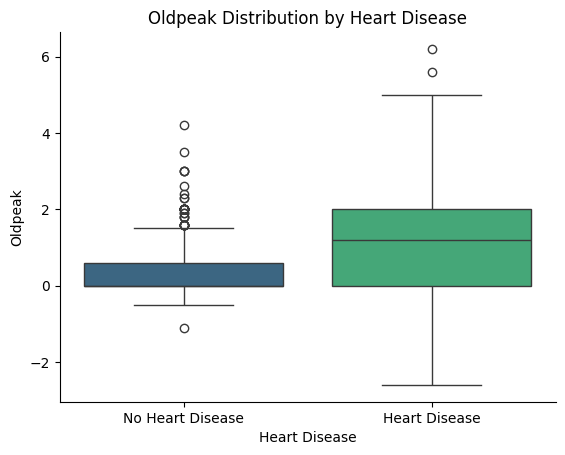

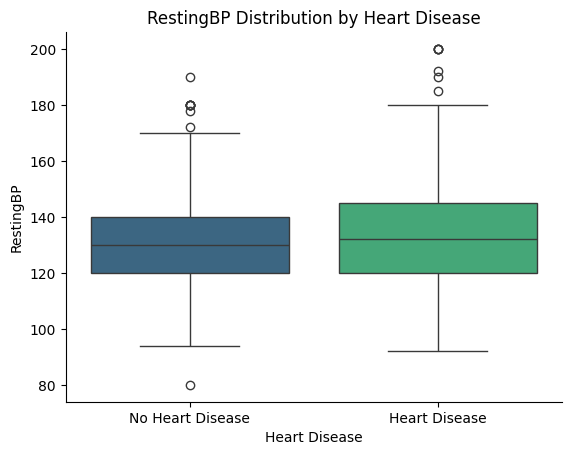

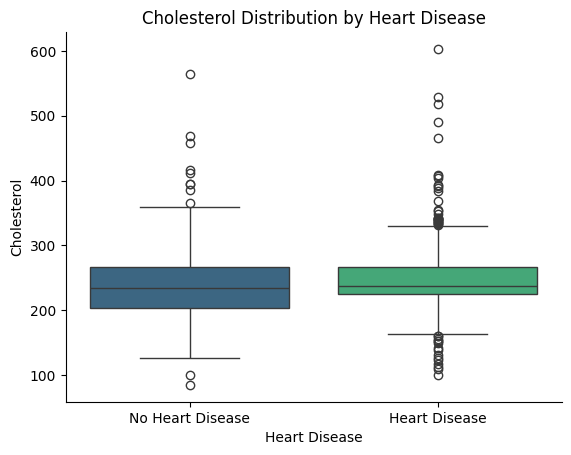

In [ ]:
# Create a list of numerical features to analyse against HeartDisease.

numerical_features = [
    'Age',
    'MaxHR',
    'Oldpeak',
    'RestingBP',
    'Cholesterol'
]


# Loop through each numerical feature.

for col in numerical_features:

    # Create a boxplot showing the distribution of the numerical feature
    # for patients with and without heart disease.

    ax = sns.boxplot(
        data=clean,
        x='HeartDisease',
        y=col,
        hue='HeartDisease',
        palette='viridis',
        legend=False
    )

    # Add a title to the chart.

    plt.title(f'{col} Distribution by Heart Disease')

    # Add a label to the x-axis.

    plt.xlabel('Heart Disease')

    # Add a label to the y-axis.

    plt.ylabel(col)

    # Change the x-axis labels to more meaningful names.

    plt.xticks(
        [0, 1],
        ['No Heart Disease', 'Heart Disease']
    )

    # Remove the top and right borders for a cleaner look.

    sns.despine(top=True, right=True)

    # Display the plot.

    plt.show()

##### **Interpretation**
**2. Numerical Columns vs. HeartDisease:**

*   **Age:** Patients with Heart Disease are, on average, older than those without Heart Disease, indicating that age is a risk factor.
*   **MaxHR:** Individuals with Heart Disease generally have a lower maximum heart rate achieved during exercise compared to those without the condition, aligning with the negative correlation observed.
*   **Oldpeak:** Patients with Heart Disease tend to have higher `Oldpeak` values. The distribution for heart disease patients is shifted towards more positive values, suggesting greater ST depression.
*   **RestingBP:** While cleaned, higher `RestingBP` values tend to be more prevalent in the heart disease group, though the correlation was weaker than other factors.
*   **Cholesterol:** After handling anomalous zero values, `Cholesterol` showed a weak positive correlation with Heart Disease. Some higher cholesterol values might be slightly more common in heart disease patients, but it's not a strong distinguishing factor on its own in this dataset.


### **Categorical against HeartDisease**

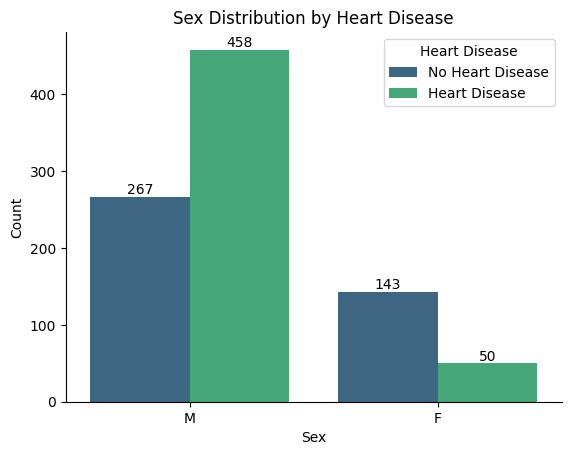

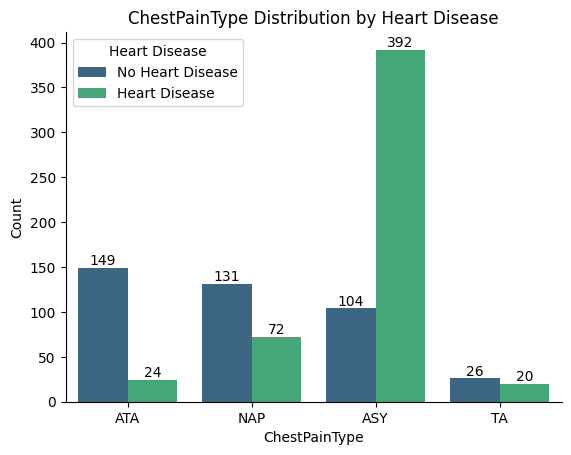

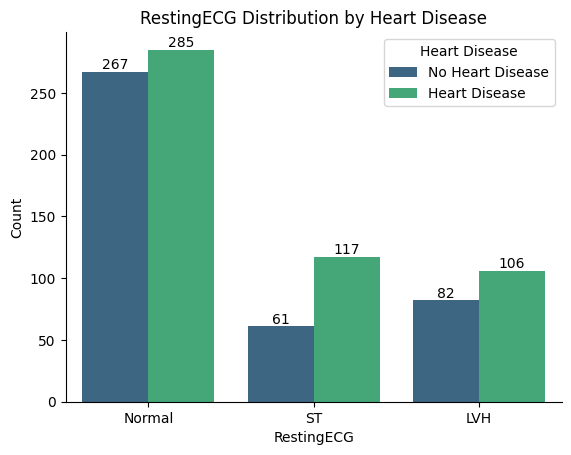

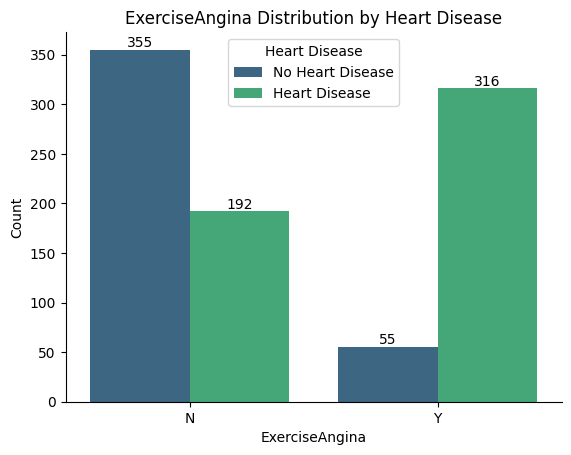

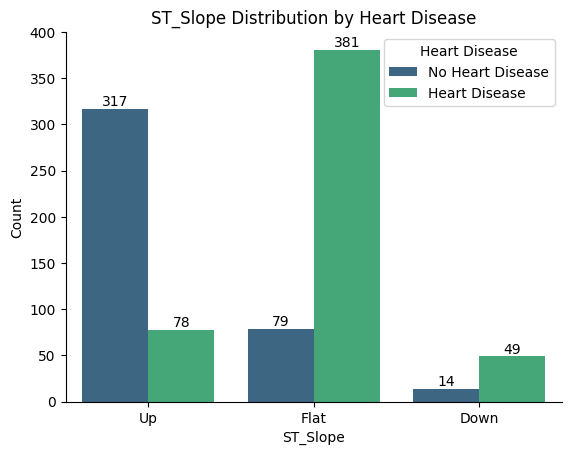

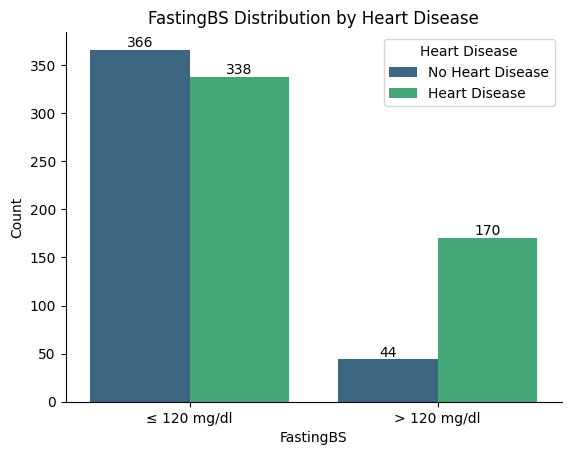

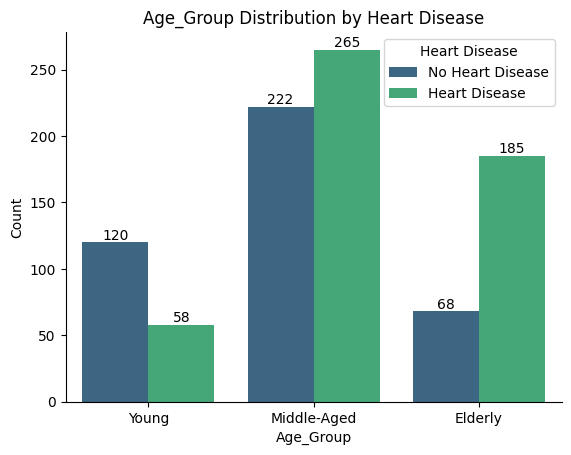

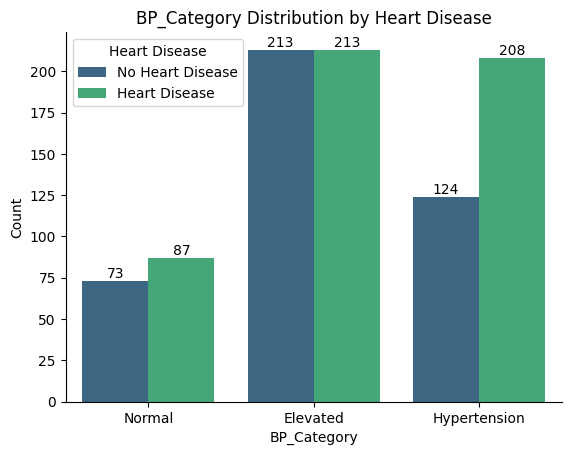

In [ ]:
# List the categorical features to analyse against HeartDisease.

categorical_features = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope',
    'FastingBS',
    'Age_Group',
    'BP_Category'
]


# Loop through each categorical feature.

for col in categorical_features:

    # Create a countplot showing the distribution of the feature by HeartDisease.

    ax = sns.countplot(
        data=clean,
        x=col,
        hue='HeartDisease',
        palette='viridis'
    )

    # Add a title to the chart.

    plt.title(f'{col} Distribution by Heart Disease')

    # Add a label to the x-axis.

    plt.xlabel(col)

    # Add a label to the y-axis.

    plt.ylabel('Count')

    # Add the count values to the top of each bar.

    for container in ax.containers:
        ax.bar_label(container)

    # Change the legend labels to more meaningful names.

    ax.legend(
        title='Heart Disease',
        labels=['No Heart Disease', 'Heart Disease']
    )

    # Remove the top and right borders for a cleaner look.
    sns.despine(top=True, right=True)

        # Change the FastingBS labels to make them easier to understand.

    if col == 'FastingBS':
        plt.xticks([0, 1], ['≤ 120 mg/dl', '> 120 mg/dl'])

    # Display the plot.
    plt.show()

##### **Interpretation**
**c. Categorical Columns vs. HeartDisease:**

*   **Sex:** Males (Sex_M = True) show a higher prevalence of heart disease in this dataset, indicating a notable gender imbalance in heart disease diagnoses within this population.
*   **ChestPainType:** `ChestPainType_ATA` (Atypical Angina) showed a strong negative correlation with heart disease, suggesting it's less common in heart disease patients. Conversely, `ASY` (Asymptomatic) chest pain is highly prevalent among patients with heart disease, making it a critical indicator despite the lack of typical symptoms.
*   **RestingECG:** While `Normal` RestingECG is common in both groups, specific abnormalities like `ST` (ST-T wave abnormality) are more pronounced in patients with heart disease, and `ST_Slope` categories like `Flat` and `Up` are very strongly correlated with heart disease status.
*   **ExerciseAngina:** The presence of `ExerciseAngina_Y` (Yes) is a strong positive indicator of Heart Disease, suggesting that exercise-induced chest pain is a significant symptom.
*   **ST_Slope:** `ST_Slope_Flat` is strongly associated with Heart Disease, while `ST_Slope_Up` is strongly negatively correlated, meaning an upsloping ST segment is highly indicative of *no* heart disease. This makes ST_Slope a very powerful predictor.
*   **FastingBS:** A higher proportion of patients with `FastingBS` = 1 (> 120 mg/dl) also have Heart Disease, indicating that elevated fasting blood sugar is a risk factor.
*   **Age_Group:** The `Elderly` age group shows a positive correlation with Heart Disease, reinforcing age as a significant factor.
*   **BP_Category:** The `Hypertension` blood pressure category shows a positive correlation with Heart Disease, suggesting that elevated blood pressure is linked to the condition.

### **B) Feature Engineering**

#### **i) Creating New Features: Age Group and Blood Pressure Category**

We will create two new categorical features: `Age_Group` and `BP_Category`. We'll use the original `Age` and `RestingBP` values from the `df` DataFrame to define these categories for more intuitive binning, and then add them to our `clean` DataFrame. Since these will be new categorical columns, they will require one-hot encoding after their creation.

Age Group distribution:
Age_Group
Middle-Aged    487
Elderly        253
Young          178
Name: count, dtype: int64

Blood Pressure Category distribution:
BP_Category
Elevated        426
Hypertension    332
Normal          160
Name: count, dtype: int64


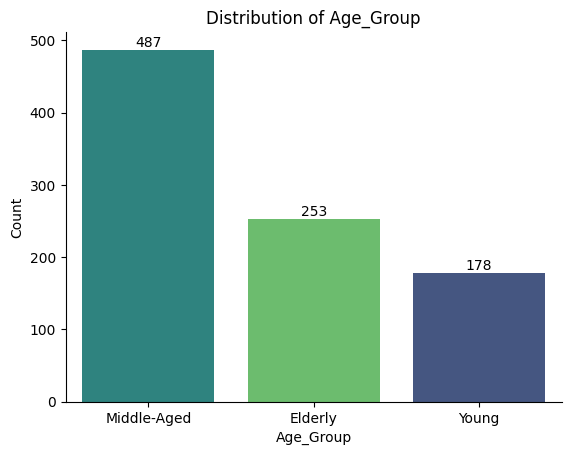

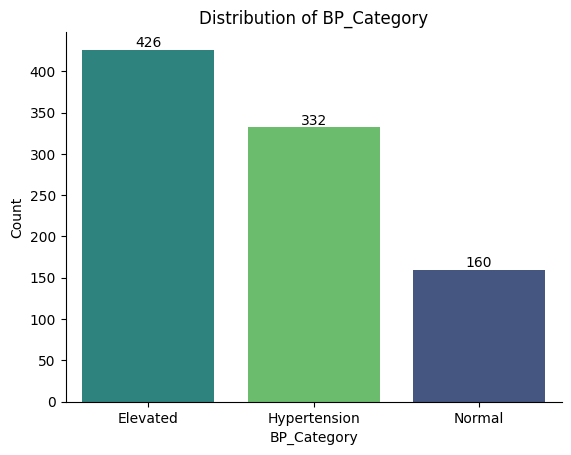

In [ ]:
# Create 'Age_Group' feature from original 'Age' data (re-creating to ensure presence)
bins_age = [0, 45, 60, np.inf]
labels_age = ['Young', 'Middle-Aged', 'Elderly']
clean['Age_Group'] = pd.cut(clean['Age'], bins=bins_age, labels=labels_age, right=False)


# Create 'BP_Category' feature from original 'RestingBP' data (re-creating to ensure presence)
bins_bp = [0, 120, 139, np.inf]
labels_bp = ['Normal', 'Elevated', 'Hypertension']
clean['BP_Category'] = pd.cut(clean['RestingBP'], bins=bins_bp, labels=labels_bp, right=False)


print("Age Group distribution:")
print(clean['Age_Group'].value_counts())

print("\nBlood Pressure Category distribution:")
print(clean['BP_Category'].value_counts())

# Now perform univariate analysis for these new categorical columns
new_categorical_cols_for_analysis = ['Age_Group', 'BP_Category']

for col in new_categorical_cols_for_analysis:

    ax = sns.countplot(data=clean, x=col, hue=col, palette='viridis', legend=False, order=clean[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')

    # Add count labels on top of bars
    for container in ax.containers:
        ax.bar_label(container)

    # Remove the top and right spines (borders) of the plot for a cleaner look.
    sns.despine(top=True, right=True)


    plt.show()

#### **ii) Remove irrelevant features**

#### **Correlation map**

#### **Justification**

**Why we performed this analysis:**

##### **Feature Understanding:**
*   It helps us quantify how strongly each numerical feature (Age, RestingBP, Cholesterol, FastingBS, MaxHR, Oldpeak) moves with the presence or absence of 'HeartDisease'.
*   A high absolute correlation value indicates a stronger linear relationship.

##### **Feature Selection (Initial Insights):**
*   Features with high correlations (positive or negative) to the target variable are often good candidates for inclusion in a predictive model.
*   They suggest that changes in these features are associated with changes in the likelihood of heart disease.

##### **Identifying Redundancy:**
*   If two independent features are highly correlated with each other, one might be redundant, or they could indicate multicollinearity, which some models are sensitive to. (Though in this specific analysis, we focused on correlation with the target).

##### **Guiding Further Exploration:**
*   Identifying features with strong correlations helps prioritize which features to examine in more detail, for example, through visualizations, to uncover non-linear relationships or group-specific patterns, which we did in the subsequent visualizations.

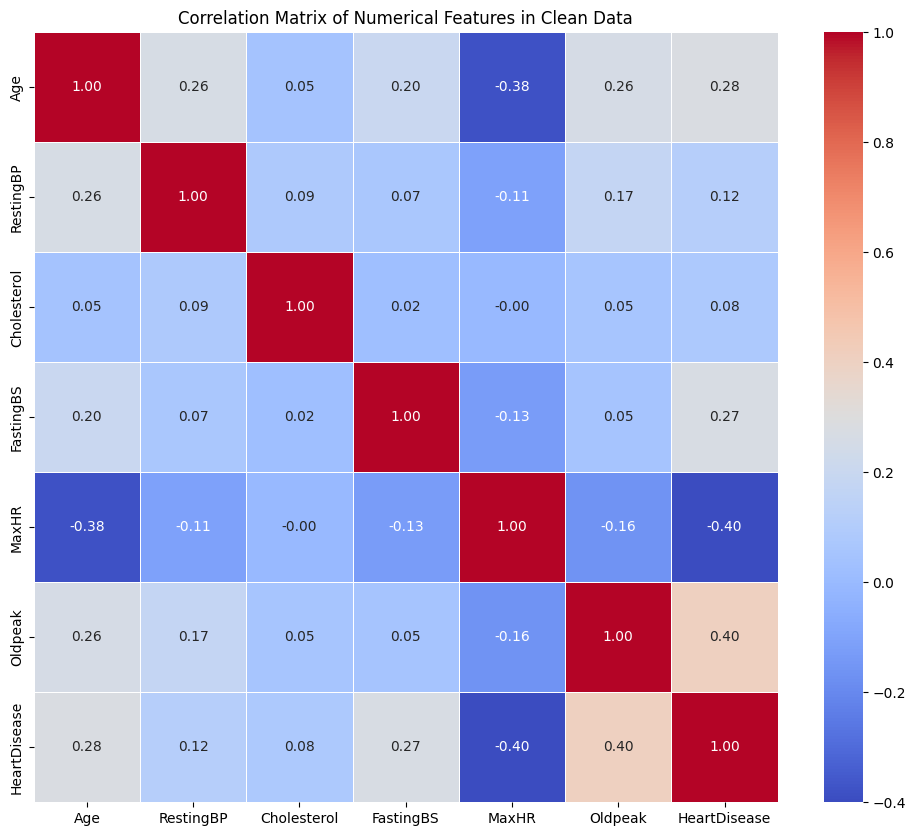

In [ ]:
# Select only numerical columns from the 'clean' DataFrame for correlation analysis
numerical_clean = clean.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_clean.corr()

# Display the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features in Clean Data')
plt.show()

#### Features with Strongest Correlation to 'HeartDisease'

In [ ]:
# Get correlations with 'HeartDisease'
heart_disease_correlations = correlation_matrix['HeartDisease'].sort_values(ascending=False)

# Exclude 'HeartDisease' itself from the list
heart_disease_correlations = heart_disease_correlations.drop('HeartDisease')

print("Features with the strongest correlation to 'HeartDisease':")
print(heart_disease_correlations)

Features with the strongest correlation to 'HeartDisease':
Oldpeak        0.403951
Age            0.282039
FastingBS      0.267291
RestingBP      0.117798
Cholesterol    0.076114
MaxHR         -0.400421
Name: HeartDisease, dtype: float64


#### **Interpretation**
Based on the correlation analysis, the features with the strongest associations with 'HeartDisease' are:

*   Oldpeak: Has the strongest positive correlation (0.40).
*   MaxHR: Has the strongest negative correlation (-0.40).
*   Age: Shows a positive correlation (0.28).
*   FastingBS: Also shows a positive correlation (0.27).


#### **C) Feature Encoding**

In [ ]:

# Identify categorical columns that need to be converted into numerical values

categorical_cols = [
    'Sex',
    'ChestPainType',
    'RestingECG',
    'ExerciseAngina',
    'ST_Slope',
    'Age_Group',
    'BP_Category'
]


# Apply One-Hot Encoding to the categorical columns
# drop_first=True removes the first category to avoid redundant columns
clean_encoded = pd.get_dummies(
    clean,
    columns=categorical_cols,
    drop_first=True
)


# Display the first 5 rows of the encoded DataFrame
#print("DataFrame after Feature Encoding:")
#print(clean_encoded.head())
clean_encoded.head()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,Age_Group_Middle-Aged,Age_Group_Elderly,BP_Category_Elevated,BP_Category_Hypertension
0,40,140.0,289.0,0,172,0.0,0,True,True,False,False,True,False,False,False,True,False,False,False,True
1,49,160.0,180.0,0,156,1.0,1,False,False,True,False,True,False,False,True,False,True,False,False,True
2,37,130.0,283.0,0,98,0.0,0,True,True,False,False,False,True,False,False,True,False,False,True,False
3,48,138.0,214.0,0,108,1.5,1,False,False,False,False,True,False,True,True,False,True,False,True,False
4,54,150.0,195.0,0,122,0.0,0,True,False,True,False,True,False,False,False,True,True,False,False,True


##### **Justification for One-Hot Encoding**
One-Hot Encoding technique is selected  for this machine-learning models because:

*   **Avoids artificial ordering:** It prevents the model from assuming that categories such as ATA, NAP, and ASY have a meaningful order or ranking.
*   **Creates a machine-readable format:** It converts categorical variables such as ChestPainType, RestingECG, Sex, and ExerciseAngina, which are nominal, into binary numerical features (0 and 1) that machine-learning algorithms can process.
*   **Prevents misleading magnitude:** Unlike Label Encoding (0, 1, 2, 3), One-Hot Encoding does not imply that one category is greater or more important than another. This is particularly appropriate for nominal variables such as ChestPainType.
*   Thus, One-Hot Encoding provided a more appropriate representation of the categorical variables for the machine-learning models used in this study.

**Methodological reference:** One-hot encoding represents categorical values as binary indicator features without imposing an artificial numerical order (scikit-learn developers, 2026).


#### **E) Outlier Detection and Handling**

Outliers are assessed and treated before feature scaling. This preserves the interpretability of the IQR boundaries in the original measurement units.


##### **i) Boxplots**

*   Create boxplots for 'FastingBS', 'MaxHR', and 'Oldpeak' from the `clean_encoded` DataFrame.


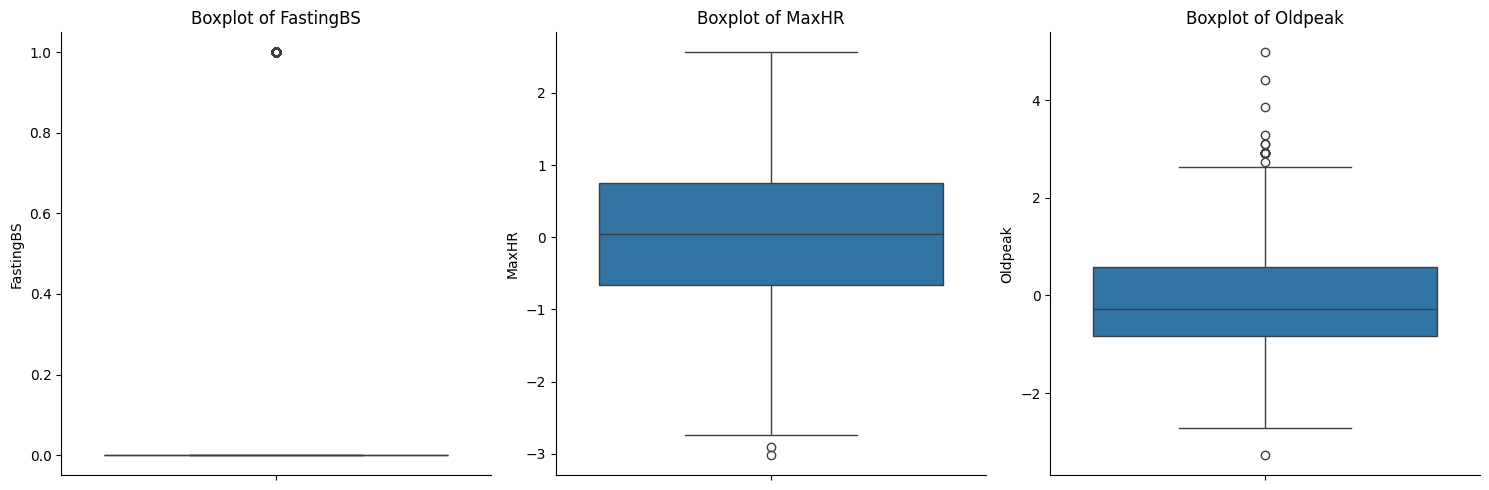

In [ ]:

# Select the numerical features to inspect for potential outliers
numerical_features = ['FastingBS', 'MaxHR', 'Oldpeak']


# Create a figure large enough to display three boxplots side by side
plt.figure(figsize=(15, 5))


# Loop through each numerical feature and create a boxplot
for i, col in enumerate(numerical_features):

    # Create a subplot for each feature
    plt.subplot(1, 3, i + 1)

    # Create a vertical boxplot to visualise the distribution
    # and identify potential outliers
    sns.boxplot(y=clean_encoded[col])

    # Add a title showing the name of the feature
    plt.title(f'Boxplot of {col}')

    # Label the y-axis with the feature name
    plt.ylabel(col)

    # Remove the top and right borders for a cleaner appearance
    sns.despine(top=True, right=True)


# Adjust the spacing between the plots
plt.tight_layout()

# Display the boxplots
plt.show()


##### **Interpretation**

#####**FastingBS Boxplot:**
*   Shows only two values (0 and 1), confirming it is a binary feature and does not require IQR-based outlier treatment.

##### **MaxHR Boxplot:**
*   Shows a fairly symmetrical distribution with some values outside the whiskers, indicating potential outliers.

##### **Oldpeak Boxplot:**
*   Shows a right-skewed distribution with several high outliers and a few low outliers.



##### **Conclusion**
##### **MaxHR Boxplot:**

*   The presence of both low and high outliers in maximum heart rate fall outside the typical range and may affect model training.

##### **Oldpeak Boxplot:**
*   The presence of several positive outliers, indicates an unusual high ST depression, along with a few negative outliers indicates ST elevation.
*   These extreme values may affect machine learning model performance and introduce bias.

#### **Justification**
##### **Why was this important:**

*  Confirmed significant outliers in MaxHR and Oldpeak.
*  Supported using IQR-based capping to reduce their impact while retaining data.
*  Confirmed FastingBS is binary and does not require IQR treatment.



##### **ii) IQR Method**


*   Calculate the IQR for 'MaxHR' and 'Oldpeak' to identify and cap outliers.
*   'FastingBS' is a binary feature and doesn't require IQR-based outlier treatment.

In [ ]:
print('--- IQR Boundaries in Original Units (before outlier capping and scaling) ---')

# Calculate for MaxHR
Q1_maxhr = clean['MaxHR'].quantile(0.25)
Q3_maxhr = clean['MaxHR'].quantile(0.75)
IQR_maxhr = Q3_maxhr - Q1_maxhr
lower_bound_maxhr = Q1_maxhr - 1.5 * IQR_maxhr
upper_bound_maxhr = Q3_maxhr + 1.5 * IQR_maxhr
print(f"\nMaxHR (Original Units):\n  Q1: {Q1_maxhr:.2f}\n  Q3: {Q3_maxhr:.2f}\n  IQR: {IQR_maxhr:.2f}\n  Lower Bound: {lower_bound_maxhr:.2f}\n  Upper Bound: {upper_bound_maxhr:.2f}")

# Calculate for Oldpeak
Q1_oldpeak = clean['Oldpeak'].quantile(0.25)
Q3_oldpeak = clean['Oldpeak'].quantile(0.75)
IQR_oldpeak = Q3_oldpeak - Q1_oldpeak
lower_bound_oldpeak = Q1_oldpeak - 1.5 * IQR_oldpeak
upper_bound_oldpeak = Q3_oldpeak + 1.5 * IQR_oldpeak
print(f"\nOldpeak (Original Units):\n  Q1: {Q1_oldpeak:.2f}\n  Q3: {Q3_oldpeak:.2f}\n  IQR: {IQR_oldpeak:.2f}\n  Lower Bound: {lower_bound_oldpeak:.2f}\n  Upper Bound: {upper_bound_oldpeak:.2f}")

In [ ]:
# Apply the IQR method to the continuous numerical features before scaling
# clean_encoded is still in original units at this stage
# FastingBS is excluded because it is a binary feature (0 or 1)
for col in ['MaxHR', 'Oldpeak']:

    # Calculate the first quartile (25th percentile)
    Q1 = clean_encoded[col].quantile(0.25)

    # Calculate the third quartile (75th percentile)
    Q3 = clean_encoded[col].quantile(0.75)

    # Calculate the Interquartile Range (IQR)
    # IQR represents the middle 50% of the data
    IQR = Q3 - Q1

    # Calculate the lower boundary for detecting potential outliers
    lower_bound = Q1 - 1.5 * IQR

    # Calculate the upper boundary for detecting potential outliers
    upper_bound = Q3 + 1.5 * IQR


    # Cap values above the upper boundary at the upper boundary
    # This prevents extreme high values from having excessive influence
    clean_encoded[col] = np.where(
        clean_encoded[col] > upper_bound,
        upper_bound,
        clean_encoded[col]
    )

    # Cap values below the lower boundary at the lower boundary
    # This prevents extreme low values from having excessive influence
    clean_encoded[col] = np.where(
        clean_encoded[col] < lower_bound,
        lower_bound,
        clean_encoded[col]
    )


    # Display the calculated boundaries used for outlier capping
    print(
        f"Outliers in {col} capped: "
        f"Lower Bound = {lower_bound:.2f}, "
        f"Upper Bound = {upper_bound:.2f}"
    )

Outliers in MaxHR capped: Lower Bound = -2.78, Upper Bound = 2.88
Outliers in Oldpeak capped: Lower Bound = -2.94, Upper Bound = 2.69


##### **Display boxplots to confirm outlier treatment**

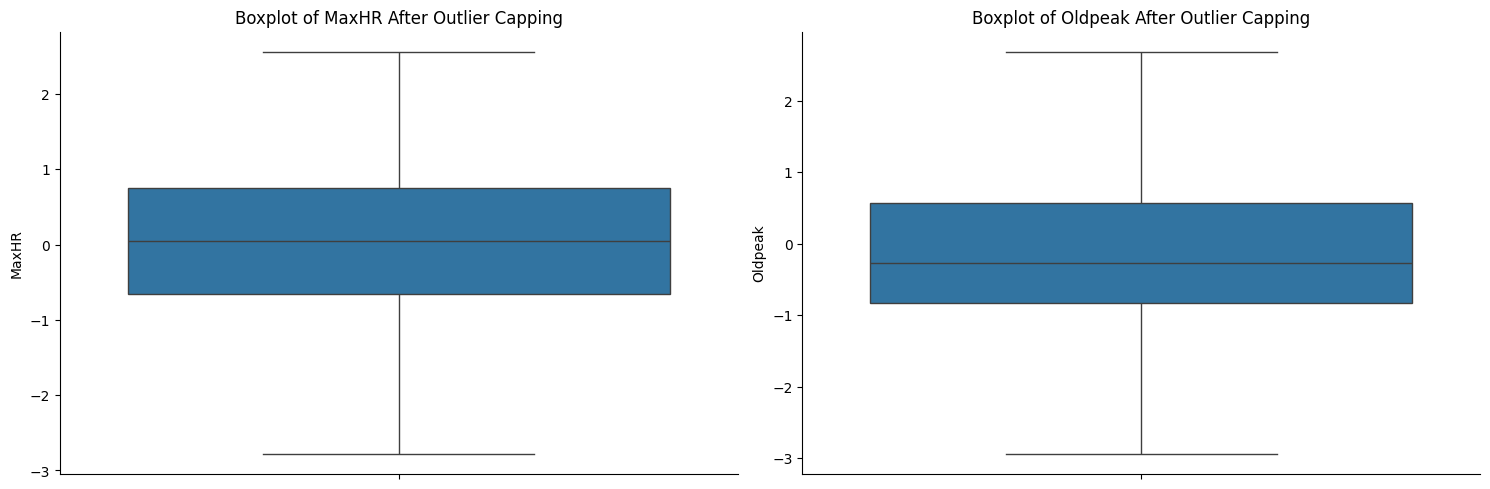

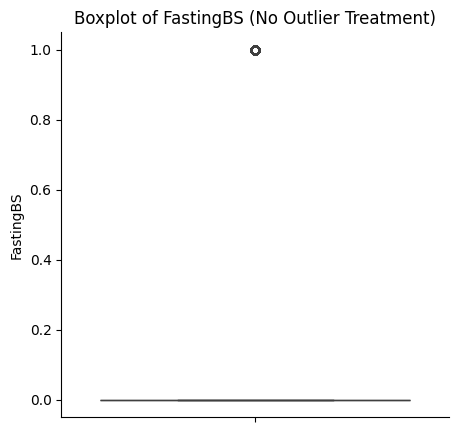

In [ ]:
# Display boxplots again to confirm outlier treatment
plt.figure(figsize=(15, 5))
for i, col in enumerate(['MaxHR', 'Oldpeak']):
    plt.subplot(1, 2, i + 1) # Adjust subplot for 2 columns
    sns.boxplot(y=clean_encoded[col])
    plt.title(f'Boxplot of {col} After Outlier Capping')
    plt.ylabel(col)
    sns.despine(top=True, right=True)
plt.tight_layout()
plt.show()

# Also show FastingBS boxplot for completeness, even if not treated
plt.figure(figsize=(5, 5))
sns.boxplot(y=clean_encoded['FastingBS'])
plt.title('Boxplot of FastingBS (No Outlier Treatment)')
plt.ylabel('FastingBS')
sns.despine(top=True, right=True)
plt.show()


##### **Interpretation of Boxplots After Outlier Capping:**

##### **MaxHR Boxplot:**
* MaxHR outliers were capped using the IQR boundaries calculated in the original measurement units before scaling.

##### **Oldpeak Boxplot:**
* Oldpeak outliers were capped using the IQR boundaries calculated in the original measurement units before scaling.

* The capped values are then standardised in the next preprocessing step.


##### **Conclusion**
##### Impact of the IQR Capping Strategy

*   **Reduced the impact of extreme values:** Limited outliers to reasonable boundaries, reducing their influence on the model.
*   **Preserved the data**: Retained all observations instead of removing rows with outliers.
*   **Improved data consistency:** Created a more contained distribution, supporting more stable model training.


##### **My Approach**
*   Boxplots were initially used to visually assess potential outliers in FastingBS, MaxHR, and Oldpeak.
*   Since FastingBS is a binary variable, it was excluded from IQR-based outlier treatment.
*   The continuous variables MaxHR and Oldpeak were assessed using the 1.5 × IQR rule, with lower and upper bounds calculated from the first and third quartiles.
*   Identified extreme values were capped at these boundaries rather than removed, allowing all patient observations to be retained while reducing the influence of extreme values.
*   Boxplots were subsequently regenerated to verify the effect of the outlier treatment.





#### **F) Feature Scaling**

Outlier treatment was completed before scaling. Standardisation is applied only after the IQR capping step so that the outlier boundaries are calculated in the original measurement units.


*   To apply StandardScaler to the numerical features, I instantiated the scaler and then use its `fit_transform` method on the specified columns.
*   I then, displayed the head and descriptive statistics of these scaled columns will confirm the transformation.

##### **Instantiate the scaler and then use its fit_transform method on the specified columns.**

In [ ]:

# Identify numerical columns to scale
numerical_cols_to_scale = ['MaxHR', 'Oldpeak']

# Initialize StandardScaler
scaler = StandardScaler()

# Apply StandardScaler to the identified numerical columns
clean_encoded[numerical_cols_to_scale] = scaler.fit_transform(clean_encoded[numerical_cols_to_scale])


##### **DataFrame after Feature Scaling (first 5 rows of scaled columns)**

In [ ]:

clean_encoded[numerical_cols_to_scale].head()

,MaxHR,Oldpeak
0,1.382928,-0.832432
1,0.754157,0.105664
2,-1.525138,-0.832432
3,-1.132156,0.574711
4,-0.581981,-0.832432


##### **Descriptive statistics for scaled numerical features**

In [ ]:
#Descriptive statistics for scaled numerical features
clean_encoded[numerical_cols_to_scale].describe()


,MaxHR,Oldpeak
count,9.180000e+02,9.180000e+02
mean,4.953675e-16,1.238419e-16
std,1.000545e+00,1.000545e+00
min,-3.018469e+00,-3.271482e+00
25%,-6.605778e-01,-8.324324e-01
50%,4.678968e-02,-2.695748e-01
75%,7.541571e-01,5.747115e-01
max,2.561874e+00,4.983762e+00


#### **G) Feature Selection**



*   First, compute the correlation matrix for the `clean_encoded` DataFrame to assess the relationship between all features, especially with the 'HeartDisease' target, and to identify potential multicollinearity among independent variables.
*   Then, display the correlations with 'HeartDisease' to inform feature selection decisions.


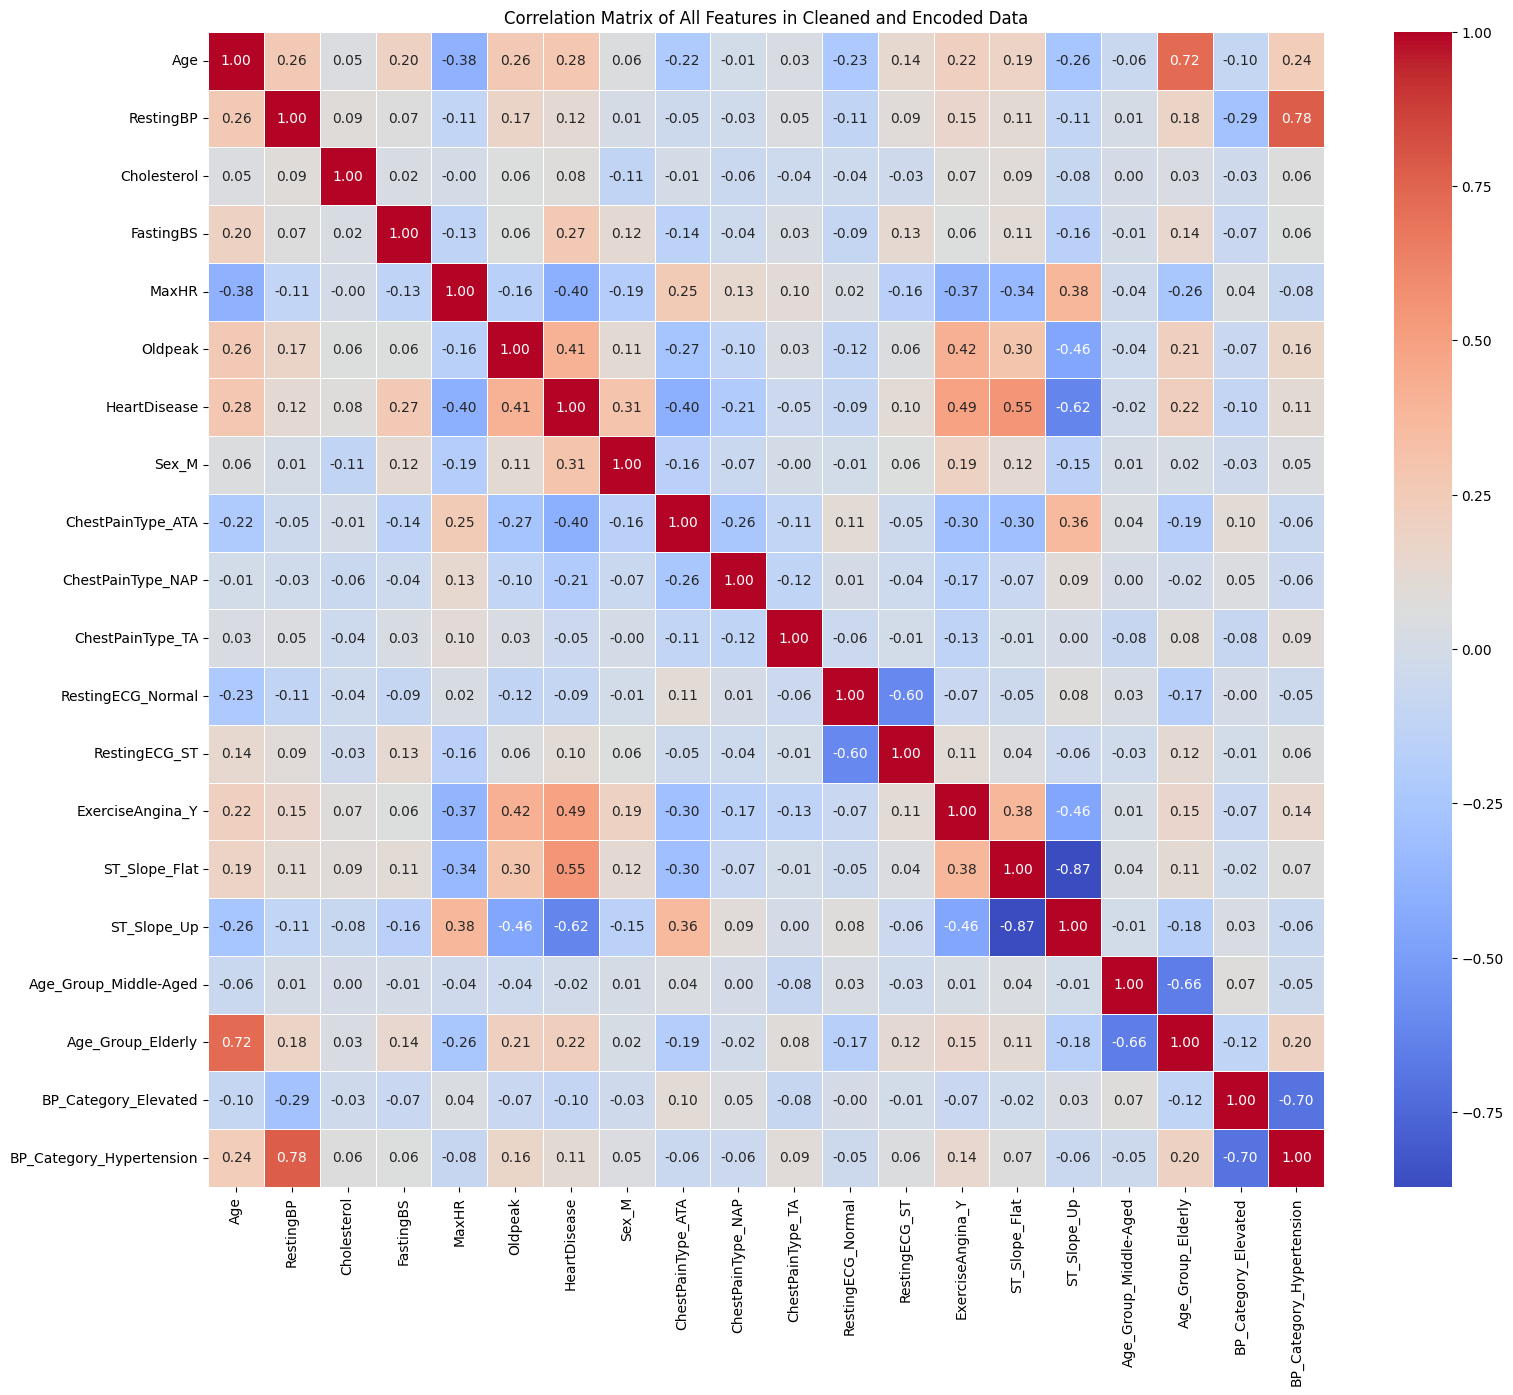

In [ ]:

# Calculate the correlation matrix for the clean_encoded DataFrame
correlation_matrix_encoded = clean_encoded.corr()

# Display the correlation matrix using a heatmap (optional, but good for visualization)
plt.figure(figsize=(18, 15))
sns.heatmap(correlation_matrix_encoded, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of All Features in Cleaned and Encoded Data')
plt.show()

# Get correlations with 'HeartDisease' for the encoded data
heart_disease_correlations_encoded = correlation_matrix_encoded['HeartDisease'].sort_values(ascending=False)



##### **Features with correlations to 'HeartDisease' (from encoded data)**


In [ ]:
heart_disease_correlations_encoded

,HeartDisease
HeartDisease,1.000000
ST_Slope_Flat,0.554134
ExerciseAngina_Y,0.494282
Oldpeak,0.410211
Sex_M,0.305445
Age,0.282039
FastingBS,0.267291
Age_Group_Elderly,0.220657
RestingBP,0.117798
BP_Category_Hypertension,0.110721


##### **Interpretation of Feature Correlations for Selection**

Based on the correlation analysis with the 'HeartDisease' target variable in the encoded dataset, we can identify key features:

1.  **Most Important Features (Strongest Correlation with 'HeartDisease'):**
    *   `ST_Slope_Flat` (0.55): Strong positive correlation, indicating that a flat ST segment is strongly associated with heart disease.
    *   `ST_Slope_Up` (-0.62): Strong negative correlation, suggesting an upsloping ST segment is highly associated with *no* heart disease. This makes it a very strong predictor.
    *   `ExerciseAngina_Y` (0.49): Strong positive correlation, meaning exercise-induced angina is a significant indicator of heart disease.
    *   `Oldpeak` (0.41): Significant positive correlation. Higher `Oldpeak` values are linked to heart disease.
    *   `MaxHR` (-0.40): Significant negative correlation. Lower maximum heart rate is associated with heart disease.
    *   `ChestPainType_ATA` (-0.40): Strong negative correlation, suggesting Atypical Angina is less common in those with heart disease.
    *   `Sex_M` (0.31): Positive correlation, implying males are more likely to have heart disease in this dataset.

2.  **Highly Correlated Variables (Potential Multicollinearity):**
    We must look at the `correlation_matrix_encoded` to identify high correlations *between independent features*. If two independent features are highly correlated (e.g., > 0.7 or 0.8), one might be redundant or cause issues for certain models.
    *   Examining the full correlation matrix (generated previously), we often find high correlations between one-hot encoded dummy variables for the *same original categorical feature*. For instance, `ST_Slope_Flat` and `ST_Slope_Up` are highly negatively correlated because they represent mutually exclusive categories of the same feature. Similar patterns exist for `ChestPainType` categories.
    *   Also, new features like `Age_Group_Elderly` and `BP_Category_Hypertension` will naturally have some correlation with `Age` and `RestingBP` respectively, but usually not to the extent of exact duplicates.
    *   The current analysis primarily focuses on correlation with the target. A deeper dive into multicollinearity amongst predictors would involve inspecting pairs with absolute correlation coefficients above a certain threshold (e.g., 0.8) and deciding whether to keep both or drop one.

3.  **Features to Consider for Removal (Weak/Negligible Correlation to 'HeartDisease'):**
    Features with very low absolute correlations to the target variable are generally less informative for predicting the outcome and can sometimes be removed to simplify the model and prevent overfitting. Based on the `heart_disease_correlations_encoded` output:
    *   `Age_Group_Middle-Aged` (-0.02)
    *   `ChestPainType_TA` (-0.05)
    *   `RestingECG_Normal` (-0.09) and `BP_Category_Elevated` (-0.099) also show relatively weak correlations, though their absolute values are slightly higher than the previous two. These could be candidates for removal depending on the desired model complexity and performance trade-offs. A common threshold for removal might be an absolute correlation less than 0.05 or 0.06.

### **Justification for Decisions:**

a)  **Correlation Heatmap (Visual Confirmation):** The heatmap visually confirms these relationships. Darker shades (blue for negative, red for positive) indicate stronger correlations. By observing the 'HeartDisease' row/column, we can quickly grasp which features have the most intense colors (strongest correlation) and which have very light colors (weak correlation).

b)  **Feature Importance Analysis (Correlation-based):** The `heart_disease_correlations_encoded` series itself serves as a **correlation-based feature importance** metric. It quantifies the linear relationship between each feature and the target variable. Features with higher absolute correlation values are considered more important in this context. While this is a good initial step, a more advanced **model-based feature importance** (e.g., from a tree-based model like Random Forest or XGBoost, or coefficients from a linear model) would typically be performed *after* model training to understand which features the chosen model found most predictive. Given that we haven't built a model yet, correlation is the best available metric for initial feature selection.

**Methodological note:** Correlation analysis is used here as an initial screening tool for identifying associations with the target and possible redundancy. Correlation alone does not establish causation or guarantee predictive importance.


#### **H) Final Machine-Learning-Ready Dataset**

Display the `.info()` and `.head()` of the `clean_encoded` DataFrame to confirm that the final dataset is ready for the next machine-learning stage.


In [ ]:
print("Info of the final prepared dataset:")
clean_encoded.info()

print("\nHead of the final prepared dataset:")
clean_encoded.head()

Info of the final prepared dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 20 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       918 non-null    int64  
 1   RestingBP                 918 non-null    float64
 2   Cholesterol               918 non-null    float64
 3   FastingBS                 918 non-null    int64  
 4   MaxHR                     918 non-null    float64
 5   Oldpeak                   918 non-null    float64
 6   HeartDisease              918 non-null    int64  
 7   Sex_M                     918 non-null    bool   
 8   ChestPainType_ATA         918 non-null    bool   
 9   ChestPainType_NAP         918 non-null    bool   
 10  ChestPainType_TA          918 non-null    bool   
 11  RestingECG_Normal         918 non-null    bool   
 12  RestingECG_ST             918 non-null    bool   
 13  ExerciseAngina_Y          918

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease,Sex_M,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_Normal,RestingECG_ST,ExerciseAngina_Y,ST_Slope_Flat,ST_Slope_Up,Age_Group_Middle-Aged,Age_Group_Elderly,BP_Category_Elevated,BP_Category_Hypertension
0,40,140.0,289.0,0,1.382928,-0.832432,0,True,True,False,False,True,False,False,False,True,False,False,False,True
1,49,160.0,180.0,0,0.754157,0.105664,1,False,False,True,False,True,False,False,True,False,True,False,False,True
2,37,130.0,283.0,0,-1.525138,-0.832432,0,True,True,False,False,False,True,False,False,True,False,False,True,False
3,48,138.0,214.0,0,-1.132156,0.574711,1,False,False,False,False,True,False,True,True,False,True,False,True,False
4,54,150.0,195.0,0,-0.581981,-0.832432,0,True,False,True,False,True,False,False,False,True,True,False,False,True


In [ ]:
from google.colab import files

# Save the final prepared DataFrame to a CSV file
output_filename = 'clean_encoded_heart_disease_data.csv'
clean_encoded.to_csv(output_filename, index=False)

# Provide a link to download the file
files.download(output_filename)

print(f"The final prepared dataset has been saved to '{output_filename}' and is available for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

The final prepared dataset has been saved to 'clean_encoded_heart_disease_data.csv' and is available for download.


## **References**

AnalystLab Africa. (2026). *Data Science Internship Programme: Week 2 – Feature Engineering & Data Preprocessing for Machine Learning*. Assignment brief.

scikit-learn developers. (2026). *Imputation of missing values*. scikit-learn documentation. https://scikit-learn.org/stable/modules/impute.html

scikit-learn developers. (2026). *OneHotEncoder*. scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

scikit-learn developers. (2026). *StandardScaler*. scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html
